# Sprint 2 - Data Quality, Joins and Outliers

**Buy Now, Pay Later merchant ranking | MAST30034 Applied Data Science**

This notebook answers the three questions set for the Sprint 2 checkpoint:

1. What NULL values appeared after joining the datasets, and what did we do with them?
2. Was anything missing that shouldn't have been, once we joined to our external dataset?
3. What does the transaction value distribution look like before and after removing outliers?

Everything below reads from `data/curated/`, which is produced by running the
pipeline in order. Nothing in this notebook transforms data - the transformations
live in `scripts/` so that they run identically whether or not anyone opens a notebook.

```
python scripts/download_external.py   # ABS data
python scripts/etl_01_raw.py          # typed copies of the source files
python scripts/etl_02_curated.py      # joins + business rules
python scripts/etl_03_features.py     # merchant-level feature table
```

In [1]:
import sys, json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
import config
from spark_session import create_spark
from pyspark.sql import functions as F

spark = create_spark("Sprint 2 - data quality")
spark.sparkContext.setLogLevel("ERROR")

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/04 15:06:30 WARN Utils: Your hostname, iphone, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/04 15:06:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/04 15:06:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. What we were given

Before looking for problems it is worth stating plainly what is in the box.

In [2]:
transactions = spark.read.parquet(str(config.CURATED_DIR / "transactions"))

overview = transactions.agg(
    F.count("*").alias("transactions"),
    F.countDistinct("merchant_abn").alias("distinct merchants"),
    F.countDistinct("user_id").alias("distinct customers"),
    F.min("order_datetime").alias("first date"),
    F.max("order_datetime").alias("last date"),
    F.sum("dollar_value").alias("total dollar value"),
).toPandas().T
overview.columns = ["value"]
overview

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,value
transactions,6044133
distinct merchants,4395
distinct customers,24081
first date,2022-02-28
last date,2022-10-26
total dollar value,"1,003,742,739.35"


### Immediate observation: very few consumers actually transact

The consumer table describes roughly half a million people, but only a small
fraction of them appear in the transaction data at all. This is not a data
error - it is how the dataset was generated - but it matters for the ranking
system, because any feature phrased as "share of all consumers" will be
misleadingly tiny. Customer counts are therefore always expressed relative to
the transacting population, never the full consumer table.

In [3]:
consumers = spark.read.parquet(str(config.RAW_DIR / "consumers"))

n_consumers = consumers.count()
n_transacting = transactions.select("user_id").distinct().count()

print(f"consumers on file:            {n_consumers:,}")
print(f"consumers with a transaction: {n_transacting:,}")
print(f"share transacting:            {n_transacting / n_consumers:.2%}")

consumers on file:            499,999
consumers with a transaction: 24,081
share transacting:            4.82%


## 2. NULLs after joining

The joins are all LEFT joins. An inner join would have produced a clean-looking
table by deleting the very rows that tell us something is wrong, so instead each
join carries a boolean flag recording whether it matched.

In [4]:
join_quality = transactions.agg(
    F.count("*").alias("total rows"),
    F.sum((~F.col("has_merchant_record")).cast("int")).alias("no merchant record"),
    F.sum((~F.col("has_consumer_record")).cast("int")).alias("no consumer record"),
).toPandas().T
join_quality.columns = ["rows"]
join_quality["% of total"] = 100 * join_quality["rows"] / join_quality.loc["total rows", "rows"]
join_quality

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,rows,% of total
total rows,6044133,100.00
no merchant record,247188,4.09
no consumer record,0,0.00


### The merchant gap is the one that matters

A block of transactions references merchant ABNs that do not appear in
`tbl_merchants` at all. These are not nulls in a field - they are entire
merchants we have money flowing through but no record for. Because the merchant
record is where `take_rate` and `category` come from, we cannot compute either
the BNPL firm's revenue or the correct outlier threshold for these rows.

Three options were considered:

| Option | Consequence |
|---|---|
| Drop the rows | Loses a meaningful share of total transaction value with no record of it |
| Impute the take rate from the category average | Impossible - the category is missing too |
| Keep, flag, exclude from ranking | Value is preserved and auditable; these merchants simply cannot be ranked |

We chose the third. These merchants are **not candidates for onboarding** —
we have no partnership record for them — so excluding them from the ranking is
correct on business grounds, not just convenient. The volume is reported below
so the exclusion is visible rather than silent.

In [5]:
unmatched = (
    transactions.filter(~F.col("has_merchant_record"))
    .agg(
        F.countDistinct("merchant_abn").alias("merchants"),
        F.count("*").alias("transactions"),
        F.sum("dollar_value").alias("dollar value"),
    )
    .toPandas()
)

total_value = transactions.agg(F.sum("dollar_value")).collect()[0][0]
unmatched["% of all dollars"] = 100 * unmatched["dollar value"] / total_value
unmatched

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,merchants,transactions,dollar value,% of all dollars
0,386,247188,"86,383,970.42",8.61


### Merchants with a record but no transactions

The opposite case also exists: merchants who signed up but have not transacted
in this window. The project spec calls these out directly - *"a new merchant
with little information on how they will perform"*. They are kept and handled
separately in the ranking system rather than being scored as though they had
zero revenue, which would rank them below merchants who are genuinely failing.

In [6]:
merchants = spark.read.parquet(str(config.RAW_DIR / "merchants"))
active = transactions.select("merchant_abn").distinct()

no_activity = merchants.join(active, "merchant_abn", "left_anti")
print(f"merchants on file with no transactions in this window: {no_activity.count()}")
no_activity.select("merchant_name", "category", "revenue_level", "take_rate").limit(10).toPandas()

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


merchants on file with no transactions in this window: 17


,merchant_name,category,revenue_level,take_rate
0,Cras Convallis Ltd,"antique shops - sales, repairs, and restoratio...",b,4.97
1,Neque Tellus Foundation,"antique shops - sales, repairs, and restoratio...",b,3.61
2,Gravida Nunc LLP,"jewelry, watch, clock, and silverware shops",b,4.57
3,Elit Dictum Eu Foundation,art dealers and galleries,a,6.40
4,Lobortis Nisi Associates,"jewelry, watch, clock, and silverware shops",d,0.88
5,Lobortis Augue Ltd,"jewelry, watch, clock, and silverware shops",c,2.01
6,Vulputate Risus A Corporation,"antique shops - sales, repairs, and restoratio...",a,6.14
7,Nam Corp.,telecom,b,4.14
8,Elit LLP,"antique shops - sales, repairs, and restoratio...",b,3.98
9,Aliquam Eu Institute,"antique shops - sales, repairs, and restoratio...",a,6.99


## 3. Joining to the external ABS data

Consumers are located by postcode; every useful ABS dataset is published by SA2
(Statistical Area Level 2). These do not nest — one postcode can span several
SA2s and vice versa — so the ABS postcode-to-SA2 correspondence file is used,
weighting each SA2's contribution by the `RATIO_FROM_TO` column.

The ABS itself warns that postcode boundaries are not authoritative and should
not be relied on for geocoding. **This is a stated assumption of the project,
not a solved problem.** Two separate mappings are built for two different uses:

- **ratio-weighted postcode attributes** — used for all modelling, because it
  avoids duplicating a consumer across several SA2s and inflating their
  transaction counts;
- **dominant SA2 per postcode** — used only for choropleth maps, where a single
  region has to be picked.

The coverage check below is the answer to *"was anything missing that shouldn't
have been?"*

In [7]:
import geo

try:
    correspondence = geo.load_correspondence()
    postcodes = [r.postcode for r in consumers.select("postcode").distinct().collect()]
    coverage = geo.coverage_report(postcodes, correspondence)
    for key, value in coverage.items():
        print(f"{key}: {value}")
except FileNotFoundError as error:
    print(error)
    print("\nRun `python scripts/download_external.py` before this cell.")

n_consumers: 3167
n_unique_postcodes: 3167
n_unmatched_consumers: 527
n_unmatched_postcodes: 527
pct_unmatched: 16.64
unmatched_examples: ['0200', '0801', '0804', '0811', '0813', '0814', '0815', '0821', '0831', '0851', '0861', '0871', '0881', '0906', '0907', '0909', '1001', '1002', '1003', '1004']


## 4. Outliers in transaction value

### Before any rules are applied

In [8]:
values = (
    transactions.select("dollar_value")
    .sample(fraction=0.15, seed=config.RANDOM_SEED)
    .toPandas()["dollar_value"]
)

print(values.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99, 0.999]).to_string())

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


count   907,258.00
mean        165.67
std         520.17
min           0.00
1%            1.26
25%          26.13
50%          62.26
75%         150.41
99%       1,603.80
99.9%     5,551.34
max      64,309.58


Two problems are visible in that summary, at opposite ends of the distribution.

**The bottom.** The minimum transaction value is a small fraction of one cent.
These cannot be real "pay in 5 instalments" purchases — you cannot split a
fraction of a cent into five payments. They are an artefact of the data
generator. Left in, they drag the mean basket size down and make merchants look
cheaper than they are.

**The top.** The distribution has a very long right tail. The naive fix — one
global dollar cap — is wrong here, because the same figure means different
things in different categories. Eight thousand dollars is an unremarkable
furniture order and an impossible florist order. The threshold is therefore
computed **within each merchant category**, at the quantile set in
`config.CATEGORY_OUTLIER_QUANTILE`.

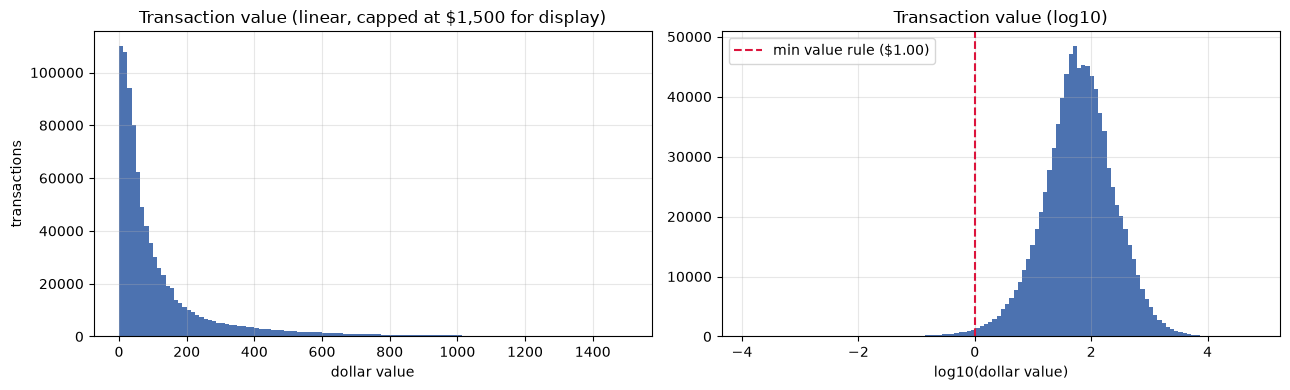

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(values, bins=120, range=(0, 1500), color="#4C72B0")
axes[0].set(title="Transaction value (linear, capped at $1,500 for display)",
            xlabel="dollar value", ylabel="transactions")

axes[1].hist(np.log10(values[values > 0]), bins=120, color="#4C72B0")
axes[1].axvline(np.log10(config.MIN_TRANSACTION_VALUE), color="crimson",
                linestyle="--", label=f"min value rule (${config.MIN_TRANSACTION_VALUE:.2f})")
axes[1].set(title="Transaction value (log10)", xlabel="log10(dollar value)")
axes[1].legend()

plt.tight_layout()
plt.show()

The log plot is the informative one: the left-hand lump below the red line is
the block of sub-cent transactions, clearly separated from the main body of
genuine purchases rather than blending into it. That separation is what
justifies a hard floor rather than a soft one.

In [10]:
# Per-category thresholds actually applied by the pipeline.
thresholds = (
    transactions.filter(F.col("category").isNotNull())
    .groupBy("category", "segment")
    .agg(
        F.first("category_upper_threshold").alias("upper threshold"),
        F.expr("percentile_approx(dollar_value, 0.5)").alias("median basket"),
        F.count("*").alias("transactions"),
    )
    .orderBy(F.desc("upper threshold"))
    .toPandas()
)
thresholds

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,category,segment,upper threshold,median basket,transactions
0,"jewelry, watch, clock, and silverware shops",Luxury & Personal Care,"38,295.99","7,900.14",2044
1,"antique shops - sales, repairs, and restoratio...",Hobby & Recreation,"28,006.40",125.25,76101
2,art dealers and galleries,Speciality Retail,"15,886.92","1,516.27",8904
3,telecom,Technology & Telecom,"11,429.66","1,207.52",14521
4,"equipment, tool, furniture, and appliance rent...",Home & Garden,"10,345.54",586.73,15694
5,motor vehicle supplies and new parts,Speciality Retail,"7,930.58",234.69,130789
6,"furniture, home furnishings and equipment shop...",Home & Garden,"5,315.26",134.01,211970
7,"hobby, toy and game shops",Hobby & Recreation,"4,732.11",85.90,100245
8,"lawn and garden supply outlets, including nurs...",Home & Garden,"4,334.93",194.41,147883
9,bicycle shops - sales and service,Hobby & Recreation,"4,049.33",110.81,95839


The spread across categories is the argument for this approach in one table: the
cap for the most expensive category sits far above the cap for the cheapest. A
single global threshold would simultaneously fail to catch impossible
transactions in low-value categories and discard legitimate ones in high-value
categories.

In [11]:
rules = transactions.agg(
    F.count("*").alias("total rows"),
    F.sum(F.col("below_min_value").cast("int")).alias("below minimum value"),
    F.sum(F.col("above_category_threshold").cast("int")).alias("above category threshold"),
    F.sum((~F.col("has_merchant_record")).cast("int")).alias("no merchant record"),
    F.sum(F.col("is_valid").cast("int")).alias("retained as valid"),
).toPandas().T
rules.columns = ["rows"]
rules["% of total"] = 100 * rules["rows"] / rules.loc["total rows", "rows"]
rules

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,rows,% of total
total rows,6044133,100.00
below minimum value,47781,0.79
above category threshold,5803,0.10
no merchant record,247188,4.09
retained as valid,5744064,95.04


### After the rules

In [12]:
clean = (
    transactions.filter(F.col("is_valid"))
    .select("dollar_value")
    .sample(fraction=0.15, seed=config.RANDOM_SEED)
    .toPandas()["dollar_value"]
)

comparison = pd.DataFrame({
    "before": values.describe(percentiles=[0.01, 0.5, 0.99]),
    "after": clean.describe(percentiles=[0.01, 0.5, 0.99]),
})
comparison["change %"] = 100 * (comparison["after"] / comparison["before"] - 1)
comparison

/home/tavish/projects/MAST30034-Project-2/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,before,after,change %
count,"907,258.00","862,482.00",-4.94
mean,165.67,156.41,-5.59
std,520.17,416.48,-19.93
min,0.00,1.00,"818,770.84"
1%,1.26,2.14,70.46
50%,62.26,61.61,-1.04
99%,"1,603.80","1,431.50",-10.74
max,"64,309.58","33,181.69",-48.40


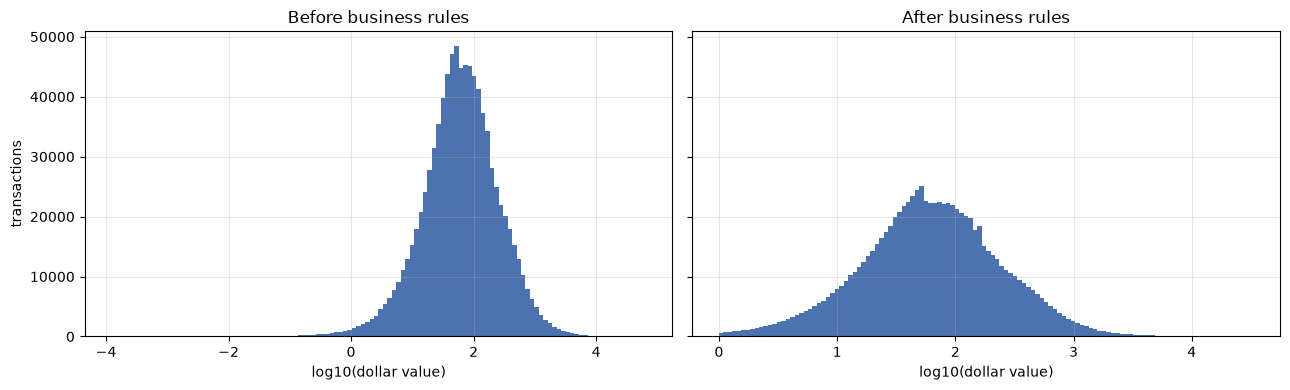

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, data, title in zip(axes, [values, clean], ["Before business rules", "After business rules"]):
    ax.hist(np.log10(data[data > 0]), bins=120, color="#4C72B0")
    ax.set(title=title, xlabel="log10(dollar value)")
axes[0].set_ylabel("transactions")

plt.tight_layout()
plt.show()

The body of the distribution is essentially unchanged — which is the point. The
rules remove the sub-cent artefacts and the extreme tail while leaving the
population of real purchases intact. A cleaning step that visibly reshaped the
middle of the distribution would be destroying signal, not noise.

## 5. The fraud labels do not cover this transaction snapshot

This is the most consequential finding in this notebook and it is a scheduling
problem, not a data-cleaning one.

The fraud probability files and the transaction snapshot in the repository
cover **different, non-overlapping time periods**. Every labelled fraud record
sits before the first transaction we hold. Joining them produces zero matches —
not a small number, zero.

In [14]:
consumer_fraud = spark.read.parquet(str(config.RAW_DIR / "consumer_fraud"))
merchant_fraud = spark.read.parquet(str(config.RAW_DIR / "merchant_fraud"))

ranges = pd.DataFrame([
    {"dataset": "transactions",
     "from": transactions.agg(F.min("order_datetime")).collect()[0][0],
     "to": transactions.agg(F.max("order_datetime")).collect()[0][0],
     "rows": transactions.count()},
    {"dataset": "consumer fraud labels",
     "from": consumer_fraud.agg(F.min("order_datetime")).collect()[0][0],
     "to": consumer_fraud.agg(F.max("order_datetime")).collect()[0][0],
     "rows": consumer_fraud.count()},
    {"dataset": "merchant fraud labels",
     "from": merchant_fraud.agg(F.min("order_datetime")).collect()[0][0],
     "to": merchant_fraud.agg(F.max("order_datetime")).collect()[0][0],
     "rows": merchant_fraud.count()},
])
ranges

,dataset,from,to,rows
0,transactions,2022-02-28,2022-10-26,6044133
1,consumer fraud labels,2021-02-28,2022-02-27,34864
2,merchant fraud labels,2021-03-25,2022-02-27,114


In [15]:
# Confirm the overlap is genuinely empty rather than merely small.
matched = transactions.join(consumer_fraud, on=["user_id", "order_datetime"], how="inner")
print(f"transactions matching a consumer fraud label: {matched.count()}")

transactions matching a consumer fraud label: 0


### What this means

Fraud labels are only useful as training data if they attach to transactions we
can compute features from. As things stand we can see *that* certain consumers
and merchants were flagged, but not *what the transaction looked like* when they
were — so there is nothing to learn a model from.

The fix is to obtain the earlier transaction snapshot covering the labelled
period. The pipeline already handles this: `etl_01_raw.py` discovers snapshot
folders by glob, so dropping the second snapshot into `tables/` requires no code
change, and a `snapshot` column is carried through so the two can be told apart.

Until then, the fraud model in Sprint 3 cannot be trained, and any merchant risk
score is limited to what can be inferred from transaction behaviour alone
(unusual value relative to a customer's own history, sudden volume spikes).
This is flagged as a project risk rather than worked around.

## 6. Summary of decisions

| Issue | Extent | Decision | Why |
|---|---|---|---|
| Transactions with no merchant record | see section 2 | Keep, flag, exclude from ranking | No take rate or category, so unrankable; and they aren't onboarding candidates |
| Merchants with no transactions | small | Keep, rank separately | Explicitly the "new merchant" case in the spec |
| Sub-cent transaction values | see section 4 | Remove via floor at `MIN_TRANSACTION_VALUE` | Cannot be a real instalment purchase; distorts mean basket |
| Extreme high values | see section 4 | Threshold **per category**, not globally | A global cap is wrong in both directions across categories |
| Postcode to SA2 mismatch | see section 3 | Ratio-weighted attributes for modelling, dominant SA2 for maps | Avoids duplicating consumers; ABS warns postcodes are not authoritative |
| Fraud labels outside transaction window | total | Blocked — need the earlier snapshot | Nothing to train on until then |

### Limitations to carry into the final presentation

1. The postcode-to-SA2 mapping is approximate and the ABS says so. Any
   demographic conclusion inherits that error.
2. The transaction window is under a year, so genuine seasonality cannot be
   separated from trend. Growth features should be read as short-run momentum.
3. Only a small share of the consumer base transacts, so demographic features
   describe the transacting population, not Australia.
4. All data is synthetic. Relationships that look strong may be generator
   artefacts rather than real consumer behaviour, and we should say so rather
   than over-claim.

In [16]:
spark.stop()